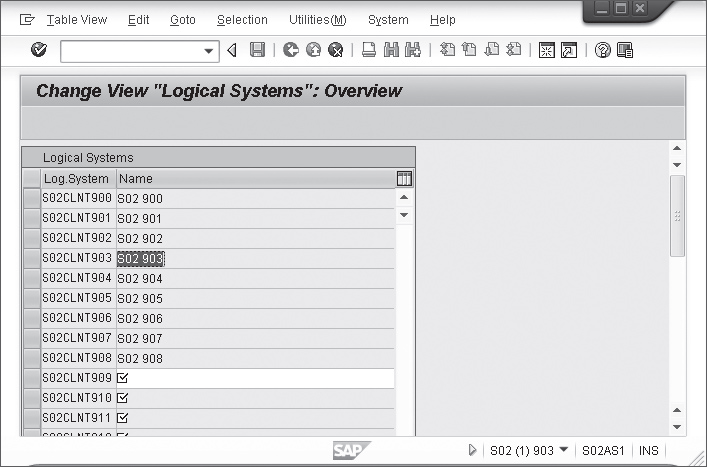

在 SAP 系统中，事务代码 **BD54** 的核心作用是**定义和管理逻辑系统（Logical Systems）**。

在 SAP 的分布式架构（如 ALE、IDoc 或 PI/PO 接口场景）中，它相当于**全网的“通信地址簿”**。

### 1. 为什么需要 BD54？

SAP 系统之间进行数据交换时，为了防止数据发错对象或被来源不明的请求干扰，每个参与通信的 SAP 实例都必须拥有一个**在全球范围内唯一的身份标识**。这个标识就是“逻辑系统”。

BD54 的主要功能就是在这个“地址簿”中为系统“挂名”。

### 2. 它的核心功能

* **创建逻辑系统名称**：你可以在这里定义系统的唯一名称（通常遵循 `<SID>CLNT<client>` 格式，如 `ERPCLNT100`）。
* **建立识别机制**：当 IDoc 数据包到达系统 B 时，系统 B 会检查数据包里的发件人代码。如果这个代码在系统 B 的 BD54 中找不到，系统会直接报错拒绝（通常提示“Logical system XXX is not known”）。

### 3. 在接口场景中的重要性

如果你正在配置接口（如你之前提到的 System A 发送数据到 System B）：

1. **在 System A 中**：你需要通过 BD54 定义好自己的名字。
2. **在 System B 中**：你**也必须**在 BD54 中手动录入 System A 的名字。
3. **结果**：只有这样，双方才能在后续的合作伙伴协议（Partner Profile，事务代码 `WE20`）中把对方添加为可信任的通信伙伴。

### 总结

你可以把 **BD54** 理解为：**为你的 SAP 系统申领一个“网络ID”**。如果这里的 ID 没配对，双方系统就像是两个完全陌生的公司，虽然有物理连接（RFC），但由于不认对方的身份，无法进行业务数据交换。

**操作提示：**
在进行接口调试时，如果你遇到“Logical system does not exist”类的报错，**第一个要检查的地方就是 BD54**，看看目标系统中是否已经录入了源系统的逻辑名。

你是在配置接口时遇到了“逻辑系统不存在”的错误，还是在进行基础的环境搭建？




we20
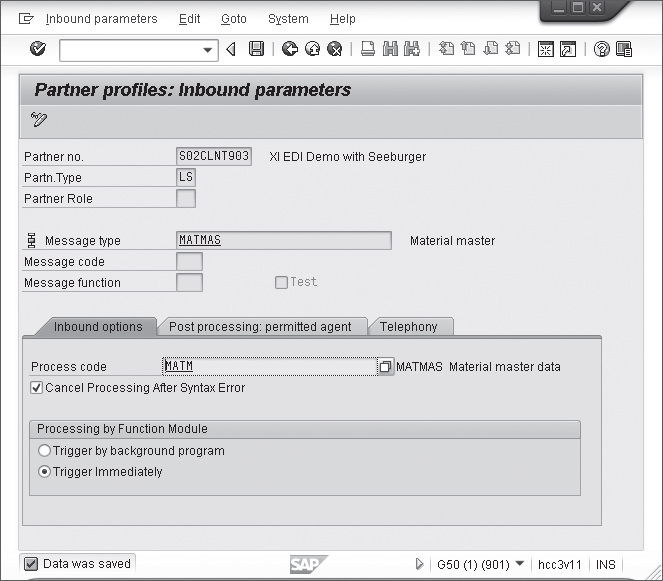
这段内容是在指导你如何完成 **WE20** 事务代码中的配置，这是在 SAP 中建立系统间信任关系的关键一步。在之前的 BD54 步骤中，你已经定义了逻辑系统的名称；现在，你需要使用 WE20 来告诉系统：“我确实接受并准备处理来自那个系统的数据”。

具体的操作步骤如下：

### 1. 创建合作伙伴协议 (Partner Agreement)

* 进入 **WE20** 后，通过菜单路径 `PARTNERS` -> `CREATE`（或者点击对应的创建图标）来新建一个协议。
* 在合作伙伴编号（Partner Number）处，输入你在之前 BD54 步骤中定义的系统 A 的逻辑系统名称。
* **非常重要**：在详细信息窗口中，必须将合作伙伴类型（Partner Type）选择为 **LS**（代表 Logical System）。
* 在“分类（Classification）”选项卡中，确保合作伙伴状态（Partner Status）设置为 **A**（代表 Active/激活）。

### 2. 配置入站参数 (Inbound Parameters)

这一步决定了当你收到数据时，系统该如何处理它。

* 保存刚才创建的合作伙伴协议。
* 在屏幕下方的“入站参数（Inbound parameters）”区域，点击“创建入站参数”图标。
* 在随后弹出的屏幕模板中，选择消息类型（Message Type）为 **MATMAS** (Master Material)。

**总结：**
这一连串操作的目的是告诉系统 B：“如果接收到来自系统 A 的、类型为 `MATMAS`（物料主数据）的 IDoc，请自动对其进行处理。” 完成这些配置后，接口的基础通信链路就打通了。


这段文字是关于在 SAP 中配置 **IDoc 入站参数（Inbound Parameters）** 的最后步骤，旨在完善你之前在 WE20 中建立的通信协议。

具体的操作指导如下：

* **选择流程代码（Process Code）**：在“入站选项（Inbound Options）”选项卡下，你需要选择预定义的流程代码 `MATM`。
* **关于错误处理的建议**：
* 在调试阶段，建议**不要**勾选“在语法错误后取消处理（Cancel processing after syntax error）”选项，这样即使出现语法错误，流程也不会立即终止，方便你后续定位和排查潜在问题。
* 一旦你的集成场景测试通过，你可以选择勾选该选项，以便在遇到语法错误时自动取消处理。


* **功能模块处理**：应立即执行“按功能模块处理（Processing by Function Module）”的选项。
* **最后步骤**：保存所有设置并退出当前事务。

完成这些步骤后，你已经成功创建了一个用于通过 IDoc 与系统 A 进行通信的合作伙伴协议。


这段内容主要是在指导你在 **Enterprise Services Repository (ESR)** 中为当前的“File-to-IDoc”练习进行对象设计。

以下是核心信息的解读：

* **复用设计对象**：教程指出，如果你已经完成了之前的练习，可以复用其中的部分对象。这些可复用的对象在表格中用星号（*）标识，包括 `MT_Material`（消息类型）和 `DT_Material`（数据类型）。
* **设计对象概览（Table 4.5）**：
* **发送方 (Sender Side)**：需要定义新的 `Service interface` (`SI_Material_Async_Out`)、`Operation mapping` 和 `Message mapping`。
* **接收方 (Receiver Side)**：直接使用标准对象 `MATMAS.MATMAS02`。


* **操作指引**：
* 你需要创建一个新的服务接口 `SI_Material_Async_Out`。
* 在创建时，该接口应选择 **OUTBOUND**（出站）类别，并且模式设置为 **ASYNCHRONOUS**（异步）。
* 输出消息（Output message）应关联到你在上一个练习中已经创建好的 `MT_Material` 消息类型。



简单来说，这是在构建接口开发的“蓝图”，通过复用旧组件和创建少量新接口定义，为将数据从文件（File）同步到 IDoc 系统做好准备。

请问你是需要在 SAP PI/PO 的 ESR 环境中进行这些对象的创建吗？